In [1]:
import os
import pickle
import glob
import sys
import getpass
import importlib
from tqdm import tqdm
from pathlib import Path

# user path:
usrname = getpass.getuser()
# add paths:
sys.path.append(f'/Users/{usrname}/Desktop/Projects')
sys.path.append(f'/Users/{usrname}/Desktop/Projects/bimanual_wrist')
sys.path.append(f'/Users/{usrname}/Desktop/Projects/Functional_Fusion')
sys.path.append(f'/Users/{usrname}/Desktop/Projects/PcmPy')

import rsatoolbox as rsa
from rsatoolbox.io import spm as spm_io
import surfAnalysisPy as surf
import SUITPy as suit
import nibabel as nb
import nitools as nt
import PcmPy as pcm
import Functional_Fusion.atlas_map as am
import Functional_Fusion.reliability as rel

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import seaborn as sns

import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
import scipy
import scipy.io as sio
import numpy as np
import pandas as pd

import utils
importlib.reload(utils)

font_path = '/Users/aghavamp/Library/Fonts/Calibri.ttf' 
fm.fontManager.addfont(font_path)
plt.rcParams.update({'font.size': 7, 'font.family':'Arial'})

# SET PATHS:
baseDir = os.path.join('/Users', getpass.getuser(), 'Desktop', 'Projects', 'bimanual_wrist', 'data', 'fMRI')
bidsDir = 'BIDS'
anatomicalDir = 'anatomicals'
freesurferDir = 'surfaceFreesurfer'
surfacewbDir = 'surfaceWB' 
behavDir = 'behavioural'
regDir = 'ROI'
atlasDir = '/Volumes/diedrichsen_data$/data/Atlas_templates/fs_LR_32'
analysisDir = os.path.join(os.path.dirname(os.path.dirname(baseDir)), 'analysis')
figDir = os.path.join(os.path.dirname(os.path.dirname(baseDir)), 'figures')


## Pearson r same movement

### estimate correlations

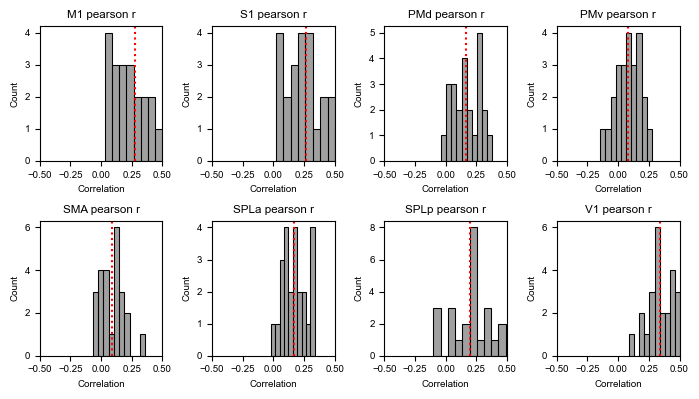

,region,r,fisher_Z
0,M1,0.287989,0.296372
1,M1,0.066414,0.066512
2,M1,0.098167,0.098484
3,M1,0.519114,0.575127
4,M1,0.466837,0.506019
...,...,...,...
187,V1,0.297980,0.307301
188,V1,0.402077,0.426124
189,V1,0.450719,0.485602
190,V1,0.462726,0.500775


In [2]:
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']

df = {'region':[], 'r':[], 'fisher_Z':[]}
for region in regions:
    uni_file = os.path.join(analysisDir, f'pcm_dataset_6by6_{region}.npz')
    marginal_file = os.path.join(analysisDir, f'pcm_dataset_marginal_{region}.npz')

    # load pcm dataset:
    D_uni = np.load(uni_file, allow_pickle=True)
    contra_idx = D_uni['identifier']=='contra'
    Y_uni = D_uni['Y'][contra_idx[0]]

    D_marginal = np.load(marginal_file, allow_pickle=True)
    contra_idx = D_marginal['identifier']=='contra'
    Y_marginal = D_marginal['Y'][contra_idx[0]]

    N_uni = len(Y_uni)
    r = []
    fisher_Z = []
    # loop on participants:
    for i in range(N_uni):
        # ================================ GET UNIMANUAL ================================
        measurements = Y_uni[i].measurements
        cond_vec = Y_uni[i].obs_descriptors['cond_vec']
        if i >= 12:
            cond_vec = cond_vec - 6
        num_voxels = measurements.shape[1]
        ncond = 6

        # Create an array to store the averaged patterns for each condition
        averaged_patterns = np.zeros((ncond, num_voxels))
        
        # Loop through each condition and calculate the average pattern
        for c in range(ncond):
            # Find rows corresponding to the current condition
            condition_indices = cond_vec == c
            # Calculate the mean pattern for the current condition
            averaged_patterns[c, :] = measurements[condition_indices, :].mean(axis=0)

        # get the contra conditions: 
        y_contra_avg = averaged_patterns
        # remove mean across conditions:
        y_contra_avg = y_contra_avg - y_contra_avg.mean(axis=0)
        # flatten the averaged patterns:
        y_contra_vec = y_contra_avg.flatten()

        # ================================ GET BIMANUAL MARGINAL ================================
        measurements = Y_marginal[i].measurements
        cond_vec = Y_marginal[i].obs_descriptors['cond_vec']
        if i >= 12:
            cond_vec = cond_vec - 6
        num_voxels = measurements.shape[1]

        # Create an array to store the averaged patterns for each condition
        averaged_patterns = np.zeros((ncond, num_voxels))

        # Loop through each condition and calculate the average pattern
        for c in range(ncond):
            # Find rows corresponding to the current condition
            condition_indices = cond_vec == c
            # Calculate the mean pattern for the current condition
            averaged_patterns[c, :] = measurements[condition_indices, :].mean(axis=0)
        
        # remove mean across conditions:
        y_marginal_avg = averaged_patterns - averaged_patterns.mean(axis=0)
        # flatten the averaged patterns:
        y_marginal_vec = y_marginal_avg.flatten()
        
        # concatenate the contra and ipsi patterns:
        r.append(np.corrcoef(y_contra_vec, y_marginal_vec)[0,1])
        fisher_Z.append(np.arctanh(r[-1]))

    r = np.array(r)
    fisher_Z = np.array(fisher_Z)
    df['region'].extend([region] * len(r))
    df['r'].extend(r)
    df['fisher_Z'].extend(fisher_Z)
df = pd.DataFrame(df)

# dist plot the correlations:
plt.rcParams.update({'font.size': 7})
fig, ax = plt.subplots(2,4,figsize=(7,4))
for region in regions:
    sns.histplot(df[df['region']==region]['r'], kde=False, color='gray', ax=ax.flatten()[regions.index(region)], bins=10)
    ax.flatten()[regions.index(region)].axvline(np.mean(df[df['region']==region]['r']), color='red', linestyle=':')
    ax.flatten()[regions.index(region)].set_xlabel('Correlation')
    ax.flatten()[regions.index(region)].set_ylabel('Count')
    ax.flatten()[regions.index(region)].set_title(f'{region} pearson r')
    ax.flatten()[regions.index(region)].set_xlim(-0.5,0.5)
plt.tight_layout()
plt.show()

df



### t-test fisher_z > 0

In [28]:
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']
df_stats = {'region': [], 'dof': [], 't': [], 'p_unc': [], 'p_fdr': []}

for region in regions:
    fisher_Z = df[df['region']==region]['fisher_Z'].values
    dof = len(fisher_Z) - 1
    t_stat, p_unc = stats.ttest_1samp(fisher_Z, 0, alternative='greater')
    df_stats['region'].append(region)
    df_stats['dof'].append(dof)
    df_stats['t'].append(t_stat)
    df_stats['p_unc'].append(p_unc)

# FDR correction:
p_values = np.array(df_stats['p_unc'])
_, p_fdr, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
df_stats['p_fdr'] = p_fdr

df_stats = pd.DataFrame(df_stats)
print(df_stats)



  region  dof          t         p_unc         p_fdr
0     M1   23   7.095349  1.576107e-07  3.152214e-07
1     S1   23   7.238601  1.140999e-07  3.042663e-07
2    PMd   23   6.791848  3.152354e-07  5.043767e-07
3    PMv   23   3.709116  5.775453e-04  5.775453e-04
4    SMA   23   4.072318  2.350032e-04  2.685751e-04
5   SPLa   23   8.055483  1.904400e-08  7.617601e-08
6   SPLp   23   6.131370  1.482002e-06  1.976003e-06
7     V1   23  15.026844  1.101807e-13  8.814459e-13


## PCM correlation bimanual with contra_uni

In [3]:
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']

for region in regions:
    uni_file = os.path.join(analysisDir, f'pcm_dataset_6by6_{region}.npz')
    marginal_file = os.path.join(analysisDir, f'pcm_dataset_marginal_{region}.npz')

    # load pcm dataset:
    D_uni = np.load(uni_file, allow_pickle=True)
    contra_idx = D_uni['identifier']=='contra'
    Y_uni = D_uni['Y'][contra_idx[0]]

    D_marginal = np.load(marginal_file, allow_pickle=True)
    contra_idx = D_marginal['identifier']=='contra'
    Y_marginal = D_marginal['Y'][contra_idx[0]]

    # make a combined dataset for the PCM analysis:
    # for each hemisphere and subject, add the two datasets togethe by 
    # 1- concatenating the measurements. 
    # 2- creating cond_vec with 12 conds (6 uni + 6 marginal) and matching the conds with each other (0with0, 1with1, 2with2, etc).
    # 3- make the appropriate part_vec
    Y = [] # initialize combined PCM dataset
    for i in range(len(Y_uni)):
        measurements_uni = Y_uni[i].measurements
        cond_vec_uni = Y_uni[i].obs_descriptors['cond_vec']
        if i >= 12:
            cond_vec_uni = cond_vec_uni - 6
        part_vec_uni = Y_uni[i].obs_descriptors['part_vec']

        measurements_marginal = Y_marginal[i].measurements
        cond_vec_marginal = Y_marginal[i].obs_descriptors['cond_vec']
        if i >= 12:
            cond_vec_marginal = cond_vec_marginal - 6
        part_vec_marginal = Y_marginal[i].obs_descriptors['part_vec']

        # concatenate measurements:
        measurements = np.concatenate((measurements_uni, measurements_marginal), axis=0)
        # create cond_vec:
        cond_vec = np.concatenate((cond_vec_uni, cond_vec_marginal + 6), axis=0)
        # create part_vec:
        part_vec = np.concatenate((part_vec_uni, part_vec_marginal), axis=0)

        x = 1
        Y.append(rsa.data.Dataset(measurements, obs_descriptors={'cond_vec': cond_vec, 'part_vec': part_vec}))

    nsteps = 200 # how many correlation models
    M = []

    # Generate the models
    for r in np.linspace(-1, 1, nsteps):
        M.append(pcm.CorrelationModel(f"{r:0.2f}", num_items=6, corr=r, cond_effect=True, within_cov=None))

    # Now make the flexible model
    Mflex = pcm.CorrelationModel("flex", num_items=6, corr=None, cond_effect=True, within_cov=None)
    M.append(Mflex)

    T, theta = pcm.fit_model_individ(Y, M, fixed_effect='block', fit_scale=False, verbose=False)

    L = T.likelihood.to_numpy()

    # express log-likelihoods relative to mean
    L = L - L.mean(axis=1).reshape(-1,1)
    maxL = L[:,-1] # Last model is the flexible
    L = L[:,0:-1] # Remove it

    # Get the correlation for each of the models
    r = np.empty((nsteps,))
    for i in range(nsteps):
        r[i]= M[i].corr

    # Get the maximum likelihood estimate of each parameter
    maxr = M[-1].get_correlation(theta[-1])
    
    # FSNR for flex model:
    theta1 = np.exp(theta[-1][2,:])
    theta2 = np.exp(theta[-1][3,:])
    theta_noise = np.exp(theta[-1][-1,:])
    fsnr = np.sqrt(theta1*theta2*10) / theta_noise

    # save results:
    outname = os.path.join(analysisDir, f'pcm_corr_unimanual_bimanual_contra_{region}.npz')
    np.savez(outname, r=r, L=L, maxr=maxr, maxL=maxL, fsnr=fsnr)



KeyboardInterrupt: 

### plot

============== M1 ==============
maxr = 1.000 +/- 0.000
============== S1 ==============
maxr = 1.000 +/- 0.000
============== PMd ==============
maxr = 0.907 +/- 0.083
============== PMv ==============
maxr = 0.583 +/- 0.169
============== SMA ==============
maxr = 0.583 +/- 0.169
============== SPLa ==============
maxr = 0.917 +/- 0.083
============== SPLp ==============
maxr = 0.750 +/- 0.138
============== V1 ==============
maxr = 1.000 +/- 0.000

  region  dof      mean           sem         t     p_unc     p_fdr  reject_H0
0     M1   23  1.000000  1.239717e-07 -1.942440  0.032213  0.082956      False
1     S1   23  1.000000  2.656077e-08 -1.605458  0.061019  0.097630      False
2    PMd   23  0.906727  8.345847e-02 -1.117599  0.137638  0.157301      False
3    PMv   23  0.583249  1.693532e-01 -2.460841  0.010896  0.043635       True
4    SMA   23  0.583424  1.693183e-01 -2.460315  0.010909  0.043635       True
5   SPLa   23  0.916667  8.333333e-02 -1.000000  0.163858  0.163858   

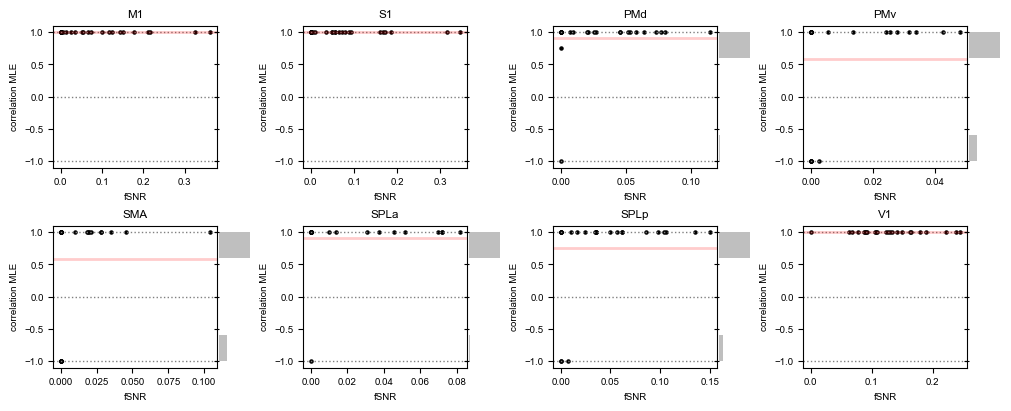

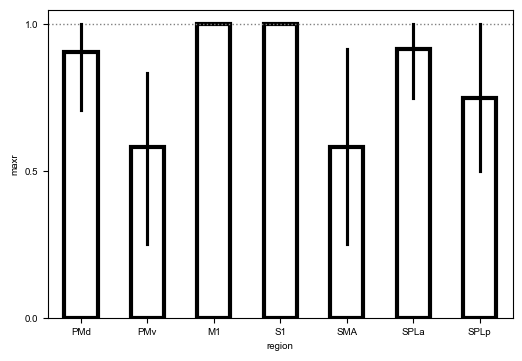

In [38]:
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']
from mpl_toolkits.axes_grid1 import make_axes_locatable  # add this import

df = {'region':[], 'maxr':[]}
df_stats = {'region': [], 'dof': [], 'mean': [], 'sem': [], 't': [], 'p_unc': []}
plt.rcParams.update({'font.size': 7})
# fig, axes = plt.subplots(2, len(regions)//2, figsize=(10,4), constrained_layout=True)
for region in regions:
    # load results:
    datafile = os.path.join(analysisDir, f'pcm_corr_unimanual_bimanual_contra_{region}.npz')
    D = np.load(datafile, allow_pickle=True)
    r = D['r']
    L = D['L']
    maxr = D['maxr']
    df['region'].extend([region] * len(maxr))
    df['maxr'].extend(maxr)
    maxL = D['maxL']
    print(f'============== {region} ==============')
    print(f'maxr = {np.mean(maxr):.3f} +/- {stats.sem(maxr):.3f}')
    
    # t-test maxr vs 1:
    t, p = stats.ttest_1samp(maxr, 1, alternative='less')
    # print(f'maxr < 1: t({len(maxr)-1})={t:1.3f}; p={p:1.6f}\n')
    df_stats['region'].append(region)
    df_stats['dof'].append(len(maxr) - 1)
    df_stats['mean'].append(np.mean(maxr))
    df_stats['sem'].append(stats.sem(maxr))
    df_stats['t'].append(t)
    df_stats['p_unc'].append(p)
df_stats = pd.DataFrame(df_stats)
# multiple test fdr correction across regions:
reject, p_corr, _, _ = multipletests(df_stats['p_unc'], alpha=0.05, method='fdr_bh')
df_stats['p_fdr'] = p_corr
df_stats['reject_H0'] = reject
print()
print(df_stats.to_string())

# average maxr across regions except for SMA and PMv:
df_stats_avg = df_stats[~df_stats['region'].isin(['SMA', 'PMv'])].copy()
df_stats_avg = df_stats_avg.groupby('region').mean().reset_index()
# find mean and sem of maxr:
mean_maxr = df_stats_avg['mean'].mean()
sem_maxr = df_stats_avg['sem'].mean()
print(f'\nAll except SMA, PMv: {mean_maxr:.3f} +/- {sem_maxr:.3f}')

# now the same for PMv and SMA:
df_stats_pm = df_stats[df_stats['region'].isin(['SMA', 'PMv'])].copy()
df_stats_pm = df_stats_pm.groupby('region').mean().reset_index()
mean_maxr_pm = df_stats_pm['mean'].mean()
sem_maxr_pm = df_stats_pm['sem'].mean()
print(f'SMA and PMv: {mean_maxr_pm:.3f} +/- {sem_maxr_pm:.3f}')

fig, axes = plt.subplots(2, len(regions)//2, figsize=(10,4), constrained_layout=True)
for region in regions:
    # load results:
    datafile = os.path.join(analysisDir, f'pcm_corr_unimanual_bimanual_contra_{region}.npz')
    D = np.load(datafile, allow_pickle=True)
    r = D['r']
    L = D['L']
    maxr = D['maxr']
    fsnr = D['fsnr']
    # Plot
    ax = axes.flatten()[regions.index(region)]
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.axhline(1, color='gray', linestyle=':', linewidth=1)
    ax.axhline(-1, color='gray', linestyle=':', linewidth=1)
    ax.axhline(np.mean(maxr), color='red', linestyle='-', linewidth=2, alpha=0.2)
    ax.scatter(fsnr, maxr, color='k', s=5)

    # --- vertical marginal histogram of correlation MLE (maxr) ---
    divider = make_axes_locatable(ax)
    ax_marg = divider.append_axes("right", size="20%", pad=0.02, sharey=ax)
    ax_marg.hist(maxr, bins=5, orientation='horizontal', color='gray', alpha=0.5, edgecolor='none')
    # clean up marginal axis
    ax_marg.set_xticks([])
    ax_marg.set_xlabel('')
    plt.setp(ax_marg.get_yticklabels(), visible=False)
    for spine in ax_marg.spines.values():
        spine.set_visible(False)
    # -------------------------------------------------------------
    ax.set_xlabel('fSNR')
    ax.set_ylabel('correlation MLE')
    ax.set_title(f'{region}')
# plt.savefig(os.path.join('figures', 'correlation_unimanual_bimanual_contra_vs_fsnr.png'), dpi=300)
plt.show()

# box plot of correlation:
# remove v1:
df = pd.DataFrame(df)
df_tmp = df[df['region']!='V1']
fig, ax = plt.subplots(figsize=(6,4))
ax.axhline(1, color='gray', linestyle=':', linewidth=1)
sns.barplot(x='region', y='maxr', data=df_tmp, ax=ax, 
            fill=False, color='k', width=0.5, linewidth=3,
            order=['PMd','PMv','M1','S1','SMA','SPLa','SPLp'])
ax.set_yticks([0, 0.5, 1])
# savefig:
plt.savefig(os.path.join(figDir, 'correlation_unimanual_bimanual_contra_vs_fsnr.pdf'), bbox_inches="tight")
plt.show()



## PCM correlation bimanual with ipsi_uni

In [21]:
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']

for region in regions:
    uni_file = os.path.join(analysisDir, f'pcm_dataset_6by6_{region}.npz')
    marginal_file = os.path.join(analysisDir, f'pcm_dataset_marginal_{region}.npz')

    # load pcm dataset:
    D_uni = np.load(uni_file, allow_pickle=True)
    ipsi_idx = D_uni['identifier']=='ipsi'
    Y_uni = D_uni['Y'][ipsi_idx[0]]

    D_marginal = np.load(marginal_file, allow_pickle=True)
    ipsi_idx = D_marginal['identifier']=='ipsi'
    Y_marginal = D_marginal['Y'][ipsi_idx[0]]

    # make a combined dataset for the PCM analysis:
    # for each hemisphere and subject, add the two datasets togethe by 
    # 1- concatenating the measurements. 
    # 2- creating cond_vec with 12 conds (6 uni + 6 marginal) and matching the conds with each other (0with0, 1with1, 2with2, etc).
    # 3- make the appropriate part_vec
    Y = [] # initialize combined PCM dataset
    for i in range(len(Y_uni)):
        measurements_uni = Y_uni[i].measurements
        cond_vec_uni = Y_uni[i].obs_descriptors['cond_vec']
        if i >= 12:
            cond_vec_uni = cond_vec_uni - 6
        part_vec_uni = Y_uni[i].obs_descriptors['part_vec']

        measurements_marginal = Y_marginal[i].measurements
        cond_vec_marginal = Y_marginal[i].obs_descriptors['cond_vec']
        if i >= 12:
            cond_vec_marginal = cond_vec_marginal - 6
        part_vec_marginal = Y_marginal[i].obs_descriptors['part_vec']

        # concatenate measurements:
        measurements = np.concatenate((measurements_uni, measurements_marginal), axis=0)
        # create cond_vec:
        cond_vec = np.concatenate((cond_vec_uni, cond_vec_marginal + 6), axis=0)
        # create part_vec:
        part_vec = np.concatenate((part_vec_uni, part_vec_marginal), axis=0)

        x = 1
        Y.append(rsa.data.Dataset(measurements, obs_descriptors={'cond_vec': cond_vec, 'part_vec': part_vec}))

    nsteps = 200 # how many correlation models
    M = []

    # Generate the models
    for r in np.linspace(-1, 1, nsteps):
        M.append(pcm.CorrelationModel(f"{r:0.2f}", num_items=6, corr=r, cond_effect=True, within_cov=None))

    # Now make the flexible model
    Mflex = pcm.CorrelationModel("flex", num_items=6, corr=None, cond_effect=True, within_cov=None)
    M.append(Mflex)

    T, theta = pcm.fit_model_individ(Y, M, fixed_effect='block', fit_scale=False, verbose=False)

    L = T.likelihood.to_numpy()

    # express log-likelihoods relative to mean
    L = L - L.mean(axis=1).reshape(-1,1)
    maxL = L[:,-1] # Last model is the flexible
    L = L[:,0:-1] # Remove it

    # Get the correlation for each of the models
    r = np.empty((nsteps,))
    for i in range(nsteps):
        r[i]= M[i].corr

    # Get the maximum likelihood estimate of each parameter
    maxr = M[-1].get_correlation(theta[-1])
    
    # FSNR for flex model:
    theta1 = np.exp(theta[-1][2,:])
    theta2 = np.exp(theta[-1][3,:])
    theta_noise = np.exp(theta[-1][-1,:])
    fsnr = np.sqrt(theta1*theta2*10) / theta_noise

    # save results:
    print(f'saving {region}')
    outname = os.path.join(analysisDir, f'pcm_corr_unimanual_bimanual_ipsi_{region}.npz')
    np.savez(outname, r=r, L=L, maxr=maxr, maxL=maxL, fsnr=fsnr)



saving M1
saving S1
saving PMd
saving PMv
saving SMA
saving SPLa
saving SPLp
saving V1


### plot

============== M1 ==============
maxr = 0.039 +/- 0.202
============== S1 ==============
maxr = 0.235 +/- 0.195
============== PMd ==============
maxr = 0.499 +/- 0.180
============== PMv ==============
maxr = 0.167 +/- 0.206
============== SMA ==============
maxr = 0.164 +/- 0.203
============== SPLa ==============
maxr = 0.667 +/- 0.155
============== SPLp ==============
maxr = 0.500 +/- 0.181
============== V1 ==============
maxr = 0.917 +/- 0.083

  region  dof      mean       sem          t         p_unc         p_fdr  reject_H0
0     M1   23  0.038617  0.201573   0.191581  4.248760e-01  4.248760e-01      False
1     S1   23  0.234832  0.195127   1.203485  1.205150e-01  1.928240e-01      False
2    PMd   23  0.499124  0.180475   2.765607  5.502235e-03  1.100447e-02       True
3    PMv   23  0.166718  0.205585   0.810945  2.128548e-01  2.446652e-01      False
4    SMA   23  0.163899  0.203200   0.806591  2.140820e-01  2.446652e-01      False
5   SPLa   23  0.666588  0.155410   4.28

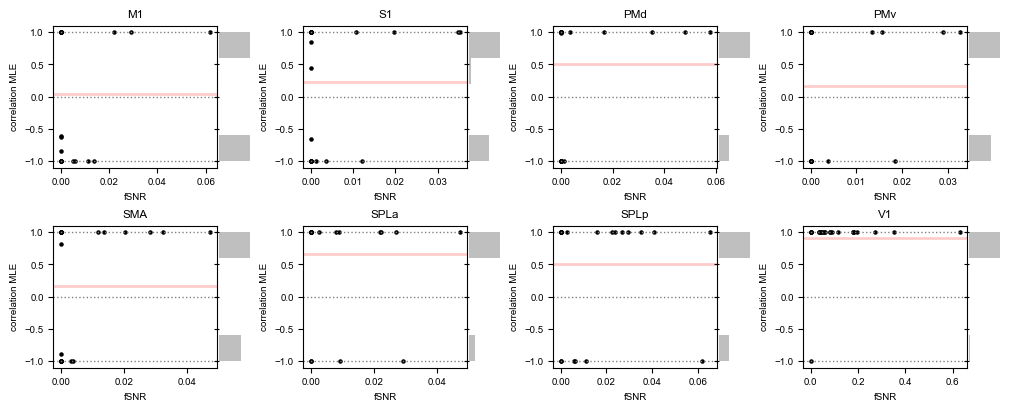

In [25]:
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']
from mpl_toolkits.axes_grid1 import make_axes_locatable  # add this import

df = {'region':[], 'maxr':[]}
df_stats = {'region': [], 'dof': [], 'mean': [], 'sem': [], 't': [], 'p_unc': []}
plt.rcParams.update({'font.size': 7})
# fig, axes = plt.subplots(2, len(regions)//2, figsize=(10,4), constrained_layout=True)
for region in regions:
    # load results:
    datafile = os.path.join(analysisDir, f'pcm_corr_unimanual_bimanual_ipsi_{region}.npz')
    D = np.load(datafile, allow_pickle=True)
    r = D['r']
    L = D['L']
    maxr = D['maxr']
    df['region'].extend([region] * len(maxr))
    df['maxr'].extend(maxr)
    maxL = D['maxL']
    print(f'============== {region} ==============')
    print(f'maxr = {np.mean(maxr):.3f} +/- {stats.sem(maxr):.3f}')
    
    # t-test maxr vs 1:
    t, p = stats.ttest_1samp(maxr, 0, alternative='greater')
    # print(f'maxr < 1: t({len(maxr)-1})={t:1.3f}; p={p:1.6f}\n')
    df_stats['region'].append(region)
    df_stats['dof'].append(len(maxr) - 1)
    df_stats['mean'].append(np.mean(maxr))
    df_stats['sem'].append(stats.sem(maxr))
    df_stats['t'].append(t)
    df_stats['p_unc'].append(p)
df_stats = pd.DataFrame(df_stats)
# multiple test fdr correction across regions:
reject, p_corr, _, _ = multipletests(df_stats['p_unc'], alpha=0.05, method='fdr_bh')
df_stats['p_fdr'] = p_corr
df_stats['reject_H0'] = reject
print()
print(df_stats.to_string())

# average maxr across regions except for SMA and PMv:
df_stats_avg = df_stats[~df_stats['region'].isin(['SMA', 'PMv'])].copy()
df_stats_avg = df_stats_avg.groupby('region').mean().reset_index()
# find mean and sem of maxr:
mean_maxr = df_stats_avg['mean'].mean()
sem_maxr = df_stats_avg['sem'].mean()
print(f'\nAll except SMA, PMv: {mean_maxr:.3f} +/- {sem_maxr:.3f}')

# now the same for PMv and SMA:
df_stats_pm = df_stats[df_stats['region'].isin(['SMA', 'PMv'])].copy()
df_stats_pm = df_stats_pm.groupby('region').mean().reset_index()
mean_maxr_pm = df_stats_pm['mean'].mean()
sem_maxr_pm = df_stats_pm['sem'].mean()
print(f'SMA and PMv: {mean_maxr_pm:.3f} +/- {sem_maxr_pm:.3f}')

fig, axes = plt.subplots(2, len(regions)//2, figsize=(10,4), constrained_layout=True)
for region in regions:
    # load results:
    datafile = os.path.join(analysisDir, f'pcm_corr_unimanual_bimanual_ipsi_{region}.npz')
    D = np.load(datafile, allow_pickle=True)
    r = D['r']
    L = D['L']
    maxr = D['maxr']
    fsnr = D['fsnr']
    # Plot
    ax = axes.flatten()[regions.index(region)]
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.axhline(1, color='gray', linestyle=':', linewidth=1)
    ax.axhline(-1, color='gray', linestyle=':', linewidth=1)
    ax.axhline(np.mean(maxr), color='red', linestyle='-', linewidth=2, alpha=0.2)
    ax.scatter(fsnr, maxr, color='k', s=5)

    # --- vertical marginal histogram of correlation MLE (maxr) ---
    divider = make_axes_locatable(ax)
    ax_marg = divider.append_axes("right", size="20%", pad=0.02, sharey=ax)
    ax_marg.hist(maxr, bins=5, orientation='horizontal', color='gray', alpha=0.5, edgecolor='none')
    # clean up marginal axis
    ax_marg.set_xticks([])
    ax_marg.set_xlabel('')
    plt.setp(ax_marg.get_yticklabels(), visible=False)
    for spine in ax_marg.spines.values():
        spine.set_visible(False)
    # -------------------------------------------------------------
    ax.set_xlabel('fSNR')
    ax.set_ylabel('correlation MLE')
    ax.set_title(f'{region}')
# plt.savefig(os.path.join('figures', 'correlation_unimanual_bimanual_contra_vs_fsnr.png'), dpi=300)
plt.show()

